# Face detection con HOG + SVM — versione rivista

**Obiettivo:** rilevare i volti in una foto con un rilevatore "classico", senza reti neurali né modelli pre-addestrati
(vincolo del caso di studio *ProCam*: fotocamera con hardware limitato).

**Pipeline:** descrittore **HOG** (Dalal & Triggs, 2005) → **SVM** con kernel RBF → **sliding window** su **piramide di immagini**
→ **hard negative mining** → **Non-Maximum Suppression**.

**Dati:** [WIDER FACE](http://shuoyang1213.me/WIDERFACE/) (Yang et al., 2016), il benchmark di riferimento per la face detection,
con i riquadri dei volti annotati a mano. Rispetto alla prima versione (selfie ritagliati con dlib + sfondi Stanford) permette
di **misurare** il rilevatore con metriche standard invece di giudicarlo su una sola foto.

---
### Note di revisione
| # | Problema nella versione precedente | Correzione |
|---|---|---|
| 1 | Nessuna metrica: il test set veniva creato ma mai valutato | AP, precisione e recall di detection su 300 immagini di validation WIDER FACE |
| 2 | Leakage: ogni volto veniva salvato anche ruotato **prima** dello split → stesse facce in train e test | split per **immagine**, augmentation solo sul training |
| 3 | Riaddestramento dopo l'hard negative mining con `C=0.1` scritto a mano | si riusano gli iperparametri migliori della ricerca |
| 4 | NMS con soglia IoU 0.05: in un selfie di gruppo volti vicini si cancellavano a vicenda | soglia 0.3 (valore standard) |
| 5 | HOG ricalcolato per ogni finestra (migliaia per immagine) | HOG calcolato **una volta per livello** della piramide e riusato: stesso risultato, molto più veloce |
| 6 | Volti "veri" ritagliati con dlib (un rilevatore pre-addestrato) | ritagli dalle annotazioni manuali di WIDER FACE |
| 7 | Foto di test protetta da copyright, percorsi Drive scritti nel codice | immagine di pubblico dominio, configurazione centralizzata |

In [1]:
import os, io, json, time, random, zipfile, shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import joblib

# --- Percorsi ---
DATA_DIR     = '/content/wider_face'           # scaricato ogni volta (non serve spazio su Drive)
DRIVE_FOLDER = '/content/drive/MyDrive/modelli_addestrati/face_detection_hog_svm'
HF_REPO      = 'CUHK-CSE/wider_face'           # copia ufficiale del dataset su Hugging Face

# --- Rilevatore ---
PATCH     = 40              # finestra 40x40 pixel
CELL      = 8               # HOG: celle 8x8, blocchi 2x2 celle, 9 orientazioni
WORK_W    = 640             # larghezza di lavoro delle immagini
SCALE     = 1.25            # passo della piramide
STEP      = 8               # passo della sliding window (multiplo della cella HOG)
NMS_IOU   = 0.3

# --- Dataset ---
MIN_FACE_TRAIN = 40         # lato minimo (px) dei volti usati per il training
N_TRAIN_IMAGES = 1500       # immagini WIDER train da cui estrarre i campioni
NEG_PER_IMAGE  = 8
N_HARD_NEG     = 3000
N_CALIB_IMAGES = 100        # immagini (train, mai viste) per scegliere la soglia operativa
N_VAL_IMAGES   = 300        # immagini WIDER val per la valutazione finale
RANDOM_STATE   = 42

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False

Mounted at /content/drive


## 1. Download di WIDER FACE e lettura delle annotazioni

In [2]:
def download_wider(data_dir=DATA_DIR):
    from huggingface_hub import hf_hub_download
    os.makedirs(data_dir, exist_ok=True)
    for name in ['wider_face_split.zip', 'WIDER_train.zip', 'WIDER_val.zip']:
        target = os.path.join(data_dir, name.replace('.zip', ''))
        if os.path.exists(target):
            continue
        path = hf_hub_download(HF_REPO, f'data/{name}', repo_type='dataset')
        with zipfile.ZipFile(path) as z:
            z.extractall(data_dir)
        print('estratto', name)

def read_annotations(split):
    # Formato: nome file, numero di volti, poi per ogni volto: x y w h blur expression illumination invalid occlusion pose
    path = os.path.join(DATA_DIR, 'wider_face_split', f'wider_face_{split}_bbx_gt.txt')
    ann, lines, i = {}, open(path).read().split('\n'), 0
    while i < len(lines) and lines[i].strip():
        name, n = lines[i].strip(), int(lines[i + 1]); i += 2
        rows = [list(map(int, lines[i + k].split()[:10])) for k in range(max(n, 1))]
        i += max(n, 1)
        ann[os.path.join(DATA_DIR, f'WIDER_{split}', 'images', name)] = np.array(rows[:n] if n else [], dtype=int).reshape(-1, 10)
    return ann

download_wider()
ann_train, ann_val = read_annotations('train'), read_annotations('val')
print(f'Immagini: train {len(ann_train):,} | val {len(ann_val):,}')
print(f'Volti annotati: train {sum(len(v) for v in ann_train.values()):,} | val {sum(len(v) for v in ann_val.values()):,}')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


data/wider_face_split.zip: reconstructing file:   0%|          |  0.00B / 3.59MB            

data/wider_face_split.zip: downloading bytes:           |  0.00B            

estratto wider_face_split.zip


data/WIDER_train.zip: reconstructing file:   0%|          |  0.00B / 1.47GB            

data/WIDER_train.zip: downloading bytes:           |  0.00B            

estratto WIDER_train.zip


data/WIDER_val.zip: reconstructing file:   0%|          |  0.00B /  363MB            

data/WIDER_val.zip: downloading bytes:           |  0.00B            

estratto WIDER_val.zip
Immagini: train 12,880 | val 3,226
Volti annotati: train 159,420 | val 39,708


## 2. HOG veloce: una volta per livello della piramide
La versione precedente calcolava l'HOG su ogni finestra 40×40. Ma se la finestra si sposta di un multiplo della cella (8 px),
i suoi blocchi HOG sono porzioni dell'HOG dell'**intera immagine**: basta calcolarlo una volta per livello e ritagliarlo.

Dettaglio importante: ai bordi di una patch isolata il gradiente non vede i pixel vicini, mentre dentro l'immagine sì
(le feature differiscono fino al 25%). Per avere **esattamente** le stesse feature in training e in detection, i campioni di
training vengono estratti con un **margine di contesto** di una cella (56×56) e se ne usano i blocchi centrali.
La cella seguente verifica l'equivalenza.

In [3]:
BLOCKS = PATCH // CELL - 1          # 4 blocchi per lato in una finestra 40x40
CTX = PATCH + 2 * CELL              # patch di training con margine di contesto: 56x56

def _hog_blocks(gray):
    return hog(gray, orientations=9, pixels_per_cell=(CELL, CELL), cells_per_block=(2, 2),
               block_norm='L2-Hys', feature_vector=False)            # (righe_blocchi, colonne_blocchi, 2, 2, 9)

def hog_patch(patch_ctx):
    # feature della finestra centrale 40x40 di una patch 56x56 (i blocchi di bordo, senza contesto, si scartano)
    return _hog_blocks(patch_ctx)[1:1 + BLOCKS, 1:1 + BLOCKS].ravel()

def hog_windows(gray):
    # feature HOG di tutte le finestre (passo = STEP) e loro coordinate in pixel, con un solo calcolo per immagine
    H = _hog_blocks(gray)
    s = STEP // CELL
    rows = range(0, H.shape[0] - BLOCKS + 1, s)
    cols = range(0, H.shape[1] - BLOCKS + 1, s)
    feats = np.array([H[r:r + BLOCKS, c:c + BLOCKS].ravel() for r in rows for c in cols])
    coords = np.array([(c * CELL, r * CELL) for r in rows for c in cols])
    return feats, coords

# Verifica: finestre interne dell'immagine == patch 56x56 con contesto ritagliate nella stessa posizione
test_img = (np.random.rand(120, 160) * 255).astype(np.uint8)
f_fast, xy = hog_windows(test_img)
inner = [(i, x, y) for i, (x, y) in enumerate(xy) if x >= CELL and y >= CELL and x + PATCH + CELL <= 160 and y + PATCH + CELL <= 120]
f_ctx = np.array([hog_patch(test_img[y - CELL:y + PATCH + CELL, x - CELL:x + PATCH + CELL]) for _, x, y in inner])
assert np.allclose(f_fast[[i for i, _, _ in inner]], f_ctx), 'HOG veloce diverso da quello per patch'
print(f'OK: {len(inner)} finestre verificate, feature identiche ({f_fast.shape[1]} valori per finestra)')

OK: 126 finestre verificate, feature identiche (576 valori per finestra)


## 3. Campioni di training: volti e non-volti
- **Volti:** ritagli quadrati dalle annotazioni (lato ≥ 40 px, non occlusi, posa frontale, non sfocati), ridotti a 40×40.
- **Non-volti:** quadrati casuali, di dimensione variabile, che **non contengono alcun volto** annotato.
- Lo split train/test è **per immagine**: nessuna foto contribuisce a entrambi. Solo sul training: flip orizzontale e piccoli
  spostamenti/zoom (±10%), perché in detection la griglia delle finestre non cade mai esattamente sul volto.

Patch train: 20,368 (volti 10,776) | test: 3,051 (volti 651) | 24s


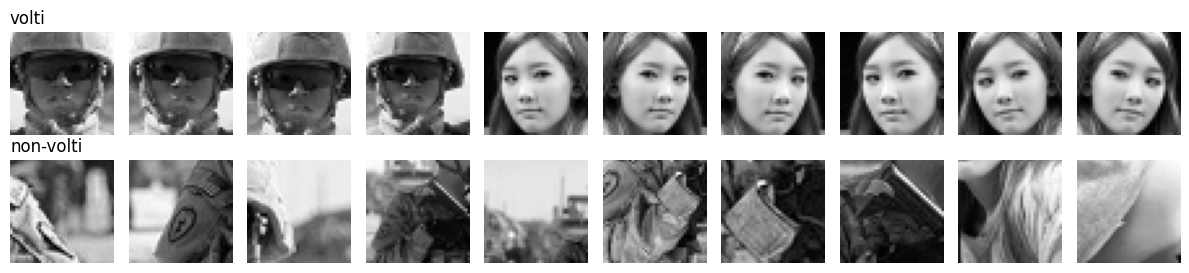

In [4]:
def to_gray(path):
    img = cv2.imread(path)
    return None if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def iou(a, b):
    xa, ya, xb, yb = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    return inter / float((a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter + 1e-9)

def good_faces(rows):
    # x y w h blur expression illumination invalid occlusion pose
    keep = (rows[:, 2] >= MIN_FACE_TRAIN) & (rows[:, 3] >= MIN_FACE_TRAIN) & (rows[:, 4] <= 1) & \
           (rows[:, 7] == 0) & (rows[:, 8] == 0) & (rows[:, 9] == 0)
    return rows[keep]

def crop_ctx(gray, x1, y1, side):
    # ritaglia il quadrato (x1, y1, side) con un margine di CELL/PATCH del lato e lo porta a 56x56
    m = int(round(side * CELL / PATCH))
    pad = cv2.copyMakeBorder(gray, m, m, m, m, cv2.BORDER_REFLECT)
    crop = pad[y1:y1 + side + 2 * m, x1:x1 + side + 2 * m]
    return cv2.resize(crop, (CTX, CTX), interpolation=cv2.INTER_AREA)

def face_patch(gray, x, y, w, h, jitter=None):
    side = int(max(w, h)); cx, cy = x + w / 2, y + h / 2
    if jitter is not None:          # piccole traslazioni/zoom: in detection la griglia non è mai perfettamente allineata al volto
        dx, dy, ds = jitter
        cx, cy, side = cx + dx * side, cy + dy * side, int(round(side * ds))
    x1, y1 = int(round(cx - side / 2)), int(round(cy - side / 2))
    if x1 < 0 or y1 < 0 or x1 + side > gray.shape[1] or y1 + side > gray.shape[0]:
        return None
    return crop_ctx(gray, x1, y1, side)

def negative_patches(gray, rows, n, rng):
    h, w = gray.shape; out, tries = [], 0
    boxes = [(x, y, x + bw, y + bh) for x, y, bw, bh in rows[:, :4]]
    while len(out) < n and tries < 50 * n:
        tries += 1
        side = rng.integers(PATCH, max(PATCH + 1, min(h, w) // 2))
        x, y = rng.integers(0, w - side + 1), rng.integers(0, h - side + 1)
        cand = (x, y, x + side, y + side)
        # nessun volto dentro il quadrato (né sovrapposto, né col centro all'interno)
        if any(iou(cand, b) > 0.05 or (x <= (b[0] + b[2]) / 2 <= x + side and y <= (b[1] + b[3]) / 2 <= y + side) for b in boxes):
            continue
        out.append(crop_ctx(gray, int(x), int(y), int(side)))
    return out

rng = np.random.default_rng(RANDOM_STATE)
candidates = [p for p, r in ann_train.items() if len(good_faces(r)) > 0]
rng.shuffle(candidates)
candidates = candidates[:N_TRAIN_IMAGES + N_CALIB_IMAGES]
split_at = int(0.8 * N_TRAIN_IMAGES)
train_imgs, test_imgs, calib_imgs = candidates[:split_at], candidates[split_at:N_TRAIN_IMAGES], candidates[N_TRAIN_IMAGES:]

def build_patches(images, augment):
    X, y, groups = [], [], []
    for gi, path in enumerate(images):
        gray = to_gray(path)
        if gray is None: continue
        rows = ann_train[path]
        for x, yy, w, h in good_faces(rows)[:, :4]:
            p = face_patch(gray, x, yy, w, h)
            if p is None: continue
            X.append(p); y.append(1); groups.append(gi)
            if augment:
                X.append(cv2.flip(p, 1)); y.append(1); groups.append(gi)
                for _ in range(2):
                    j = face_patch(gray, x, yy, w, h, jitter=(rng.uniform(-.1, .1), rng.uniform(-.1, .1), rng.uniform(.9, 1.15)))
                    if j is not None:
                        X.append(j if rng.random() < .5 else cv2.flip(j, 1)); y.append(1); groups.append(gi)
        for p in negative_patches(gray, rows, NEG_PER_IMAGE, rng):
            X.append(p); y.append(0); groups.append(gi)
    return np.array(X), np.array(y), np.array(groups)

t0 = time.time()
P_train, y_train, g_train = build_patches(train_imgs, augment=True)
P_test, y_test, _ = build_patches(test_imgs, augment=False)
print(f'Patch train: {len(y_train):,} (volti {y_train.sum():,}) | test: {len(y_test):,} (volti {y_test.sum():,}) | {time.time()-t0:.0f}s')

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for ax, p in zip(axes[0], P_train[y_train == 1][:10]): ax.imshow(p[CELL:-CELL, CELL:-CELL], cmap='gray'); ax.axis('off')
for ax, p in zip(axes[1], P_train[y_train == 0][:10]): ax.imshow(p[CELL:-CELL, CELL:-CELL], cmap='gray'); ax.axis('off')
axes[0, 0].set_title('volti', loc='left'); axes[1, 0].set_title('non-volti', loc='left')
plt.tight_layout(); plt.show()

## 4. Classificatore: HOG → StandardScaler → PCA → SVM (RBF)
Ricerca degli iperparametri con cross-validation **raggruppata per immagine** (`GroupKFold`), ottimizzando l'average precision.
Per la sliding window si usa la distanza dall'iperpiano (`decision_function`) come punteggio: non serve la calibrazione
`probability=True`, che moltiplica per 5 il tempo di addestramento.

In [8]:
F_train = np.array([hog_patch(p) for p in P_train])
F_test = np.array([hog_patch(p) for p in P_test])

from sklearn.kernel_approximation import Nystroem
from sklearn.svm import LinearSVC

# SVM con kernel RBF approssimato (Nystroem, 1000 componenti) + SVM lineare.
# Con SVC(kernel='rbf') esatto ogni finestra va confrontata con decine di migliaia di support vector: in un primo run
# la detection richiedeva quasi un minuto per immagine. L'approssimazione mantiene il confine non lineare
# ma costa un prodotto con 1000 componenti: su hardware limitato è la differenza tra usabile e inutilizzabile.
def make_model():
    return Pipeline([('scaler', StandardScaler()), ('pca', PCA(whiten=True, random_state=RANDOM_STATE)),
                     ('rbf', Nystroem(kernel='rbf', n_components=1000, random_state=RANDOM_STATE)),
                     ('svm', LinearSVC(class_weight='balanced', max_iter=5000))])

search = RandomizedSearchCV(make_model(), {'pca__n_components': [0.9, 0.95], 'rbf__gamma': [0.003, 0.01, 0.03], 'svm__C': [0.1, 1, 10]},
                            n_iter=8, cv=GroupKFold(n_splits=3), scoring='average_precision',
                            random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
t0 = time.time()
search.fit(F_train, y_train, groups=g_train)
best_params = search.best_params_
print(f'Migliori iperparametri: {best_params} (AP in CV {search.best_score_:.4f}) · {(time.time()-t0)/60:.1f} min')

def patch_report(model, name):
    s = model.decision_function(F_test)
    print(f'--- {name}: ROC AUC {roc_auc_score(y_test, s):.4f} · AP {average_precision_score(y_test, s):.4f}')
    print(classification_report(y_test, (s > 0).astype(int), target_names=['non-volto', 'volto'], digits=3))

model = search.best_estimator_
patch_report(model, 'Modello base (patch di test)')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Migliori iperparametri: {'svm__C': 10, 'rbf__gamma': 0.01, 'pca__n_components': 0.9} (AP in CV 0.9823) · 2.5 min
--- Modello base (patch di test): ROC AUC 0.9876 · AP 0.9687
              precision    recall  f1-score   support

   non-volto      0.982     0.950     0.966      2400
       volto      0.836     0.937     0.883       651

    accuracy                          0.947      3051
   macro avg      0.909     0.944     0.925      3051
weighted avg      0.951     0.947     0.948      3051



## 5. Sliding window, piramide e NMS

In [9]:
def nms(dets, thr=NMS_IOU):
    dets = sorted(dets, key=lambda d: d[4], reverse=True); keep = []
    while dets:
        cur = dets.pop(0); keep.append(cur)
        dets = [d for d in dets if iou(cur, d) < thr]
    return keep

def detect(gray, model, score_thr=0.0, work_w=WORK_W):
    # Restituisce [(x1, y1, x2, y2, score)] nelle coordinate dell'immagine originale
    h0, w0 = gray.shape
    scale0 = w0 / work_w
    img = cv2.resize(gray, (work_w, int(round(h0 / scale0))), interpolation=cv2.INTER_AREA)
    dets, level_scale = [], 1.0
    while img.shape[0] >= PATCH and img.shape[1] >= PATCH:
        feats, xy = hog_windows(img)
        if len(feats):
            scores = model.decision_function(feats)
            f = scale0 * level_scale
            for (x, y), s in zip(xy[scores > score_thr], scores[scores > score_thr]):
                dets.append((x * f, y * f, (x + PATCH) * f, (y + PATCH) * f, float(s)))
        level_scale *= SCALE
        img = cv2.resize(img, (int(img.shape[1] / SCALE), int(img.shape[0] / SCALE)), interpolation=cv2.INTER_AREA)
    return nms(dets)

t0 = time.time(); _ = detect(to_gray(calib_imgs[0]), model)
print(f'Tempo di rilevamento su un\'immagine: {time.time()-t0:.2f}s')

Tempo di rilevamento su un'immagine: 3.41s


## 6. Hard negative mining
Il modello base viene fatto scorrere sulle immagini di **training**: ogni finestra con punteggio positivo che **non** corrisponde
a un volto annotato è un falso positivo "difficile" (mani, tessuti, texture). Questi campioni vengono aggiunti come non-volti
e il modello viene riaddestrato **con gli stessi iperparametri migliori**.

Hard negatives trovati: 3,000 · 1.4 min
--- Modello finale, dopo hard negative mining (patch di test): ROC AUC 0.9875 · AP 0.9710
              precision    recall  f1-score   support

   non-volto      0.978     0.977     0.977      2400
       volto      0.915     0.920     0.917       651

    accuracy                          0.965      3051
   macro avg      0.946     0.948     0.947      3051
weighted avg      0.965     0.965     0.965      3051



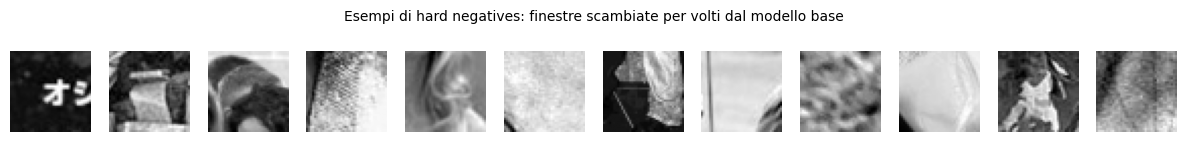

In [10]:
def mine_hard_negatives(model, images, n_max):
    hard = []
    for path in images:
        gray = to_gray(path)
        if gray is None: continue
        boxes = [(x, y, x + w, y + h) for x, y, w, h in ann_train[path][:, :4]]
        for x1, y1, x2, y2, s in detect(gray, model, score_thr=0.0):
            if all(iou((x1, y1, x2, y2), b) < 0.1 for b in boxes):
                side = int(round(x2 - x1)); x1, y1 = int(round(x1)), int(round(y1))
                if x1 >= 0 and y1 >= 0 and x1 + side <= gray.shape[1] and y1 + side <= gray.shape[0]:
                    hard.append(crop_ctx(gray, x1, y1, side))
        if len(hard) >= n_max: break
    return np.array(hard[:n_max])

t0 = time.time()
P_hard = mine_hard_negatives(model, train_imgs, N_HARD_NEG)
print(f'Hard negatives trovati: {len(P_hard):,} · {(time.time()-t0)/60:.1f} min')

F_hard = np.array([hog_patch(p) for p in P_hard]).reshape(-1, F_train.shape[1])
final = make_model().set_params(**best_params)
final.fit(np.vstack([F_train, F_hard]), np.concatenate([y_train, np.zeros(len(F_hard), int)]))
patch_report(final, 'Modello finale, dopo hard negative mining (patch di test)')

fig, axes = plt.subplots(1, 12, figsize=(12, 1.4))
for ax, p in zip(axes, P_hard[rng.choice(len(P_hard), size=min(12, len(P_hard)), replace=False)]):
    ax.imshow(p[CELL:-CELL, CELL:-CELL], cmap='gray'); ax.axis('off')
fig.suptitle('Esempi di hard negatives: finestre scambiate per volti dal modello base', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Valutazione di detection su WIDER FACE (validation)
Protocollo:
- 300 immagini di validation, mai viste in training;
- un rilevamento è corretto se **IoU ≥ 0.5** con un volto annotato (criterio PASCAL VOC);
- la finestra minima è 40×40 px a 640 px di larghezza: i volti più piccoli di così non sono rilevabili per costruzione e vengono
  marcati come **"ignora"** (non contano come mancati, e un rilevamento su di essi non conta come errore);
- metrica principale: **Average Precision (AP)**, l'area sotto la curva precisione-richiamo.

La stessa funzione di valutazione verrà usata nel notebook 02 per il confronto con YuNet.

Volti valutati: 363 su 300 immagini
AP@0.5 = 0.263
Alla soglia operativa (1.13): precisione 0.261 · recall 0.427
Tempo medio per immagine (CPU): 3.18s


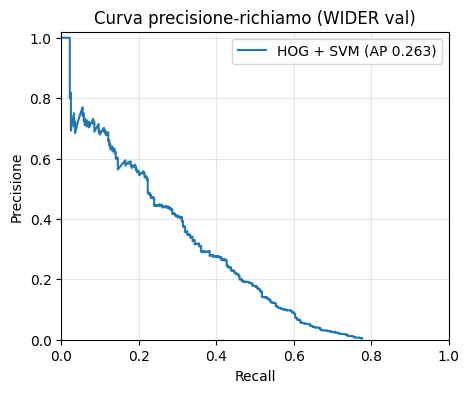

In [11]:
def split_gt(rows, img_w):
    # volti "valutati" (abbastanza grandi per la finestra minima) e volti da ignorare
    min_side = PATCH * img_w / WORK_W
    boxes = [(x, y, x + w, y + h) for x, y, w, h in rows[:, :4]]
    valid = (rows[:, 2] >= min_side) & (rows[:, 3] >= min_side) & (rows[:, 7] == 0) if len(rows) else np.array([], bool)
    return [b for b, v in zip(boxes, valid) if v], [b for b, v in zip(boxes, valid) if not v]

def evaluate(all_dets, all_gt, iou_thr=0.5):
    # all_dets: {img: [(x1,y1,x2,y2,score)]}; all_gt: {img: (valutati, ignorati)} -> AP, curva P-R, soglie
    records, n_gt = [], sum(len(g[0]) for g in all_gt.values())
    for img, dets in all_dets.items():
        gt, ign = all_gt[img]; used = [False] * len(gt)
        for d in sorted(dets, key=lambda d: d[4], reverse=True):
            ious = [iou(d, g) for g in gt]
            j = int(np.argmax(ious)) if ious else -1
            if j >= 0 and ious[j] >= iou_thr and not used[j]:
                used[j] = True; records.append((d[4], 1))
            elif any(iou(d, g) >= iou_thr for g in ign):
                continue                                     # rilevamento su un volto "ignora": non conta
            else:
                records.append((d[4], 0))
    records.sort(key=lambda r: r[0], reverse=True)
    tp = np.cumsum([r[1] for r in records]); fp = np.cumsum([1 - r[1] for r in records])
    recall = tp / max(n_gt, 1); precision = tp / np.maximum(tp + fp, 1)
    prec_env = np.maximum.accumulate(precision[::-1])[::-1] if len(precision) else precision
    ap = float(np.sum(np.diff(np.concatenate([[0], recall])) * prec_env)) if len(recall) else 0.0
    return {'AP': ap, 'precision': precision, 'recall': recall, 'scores': np.array([r[0] for r in records]), 'n_gt': n_gt}

def best_f1_threshold(res):
    f1 = 2 * res['precision'] * res['recall'] / np.maximum(res['precision'] + res['recall'], 1e-9)
    i = int(np.argmax(f1)); return res['scores'][i], res['precision'][i], res['recall'][i], f1[i]

def run_detector(fn, images, ann):
    dets, gts, t0 = {}, {}, time.time()
    for path in images:
        img = cv2.imread(path)
        dets[path] = fn(img); gts[path] = split_gt(ann[path], img.shape[1])
    return dets, gts, (time.time() - t0) / len(images)

hog_fn = lambda img: detect(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), final, score_thr=-0.5)

# 1) soglia operativa scelta su immagini di training mai viste (non sul test!)
d_cal, g_cal, _ = run_detector(hog_fn, calib_imgs, ann_train)
thr_hog, *_ = best_f1_threshold(evaluate(d_cal, g_cal))

# 2) valutazione su WIDER val
val_imgs = sorted(ann_val)
rng_val = np.random.default_rng(RANDOM_STATE)
val_imgs = [val_imgs[i] for i in rng_val.choice(len(val_imgs), size=min(N_VAL_IMAGES, len(val_imgs)), replace=False)]
d_val, g_val, sec_per_img = run_detector(hog_fn, val_imgs, ann_val)
res = evaluate(d_val, g_val)
op = evaluate({k: [d for d in v if d[4] >= thr_hog] for k, v in d_val.items()}, g_val)
print(f'Volti valutati: {res["n_gt"]:,} su {len(val_imgs)} immagini')
print(f'AP@0.5 = {res["AP"]:.3f}')
print(f'Alla soglia operativa ({thr_hog:.2f}): precisione {op["precision"][-1]:.3f} · recall {op["recall"][-1]:.3f}')
print(f'Tempo medio per immagine (CPU): {sec_per_img:.2f}s')

plt.figure(figsize=(5, 4))
plt.plot(res['recall'], res['precision'], label=f'HOG + SVM (AP {res["AP"]:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precisione'); plt.title('Curva precisione-richiamo (WIDER val)')
plt.xlim(0, 1); plt.ylim(0, 1.02); plt.legend(); plt.grid(alpha=.3); plt.show()

## 8. Esempio su un'immagine di pubblico dominio

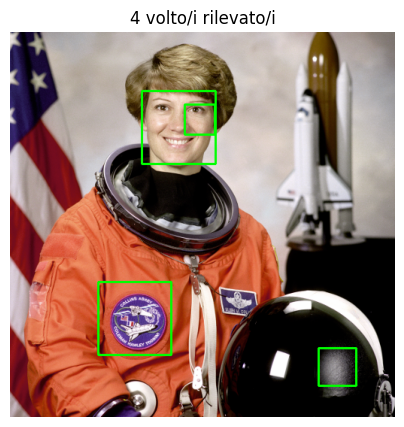

In [12]:
from skimage import data as skdata
example = cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2BGR)        # NASA, pubblico dominio
dets = [d for d in detect(cv2.cvtColor(example, cv2.COLOR_BGR2GRAY), final) if d[4] >= thr_hog]
vis = example.copy()
for x1, y1, x2, y2, s in dets:
    cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
plt.figure(figsize=(5, 5)); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.title(f'{len(dets)} volto/i rilevato/i'); plt.show()

## 9. Salvataggio

In [13]:
os.makedirs(DRIVE_FOLDER if IN_COLAB else '/tmp/face_hog', exist_ok=True)
out = DRIVE_FOLDER if IN_COLAB else '/tmp/face_hog'
joblib.dump(final, os.path.join(out, 'hog_svm_pipeline.joblib'))       # solo componenti sklearn standard
config = {'PATCH': PATCH, 'CELL': CELL, 'WORK_W': WORK_W, 'SCALE': SCALE, 'STEP': STEP, 'NMS_IOU': NMS_IOU,
          'score_threshold': float(thr_hog), 'best_params': {k: (v if not isinstance(v, np.generic) else v.item()) for k, v in best_params.items()}}
json.dump(config, open(os.path.join(out, 'config.json'), 'w'), indent=2)
json.dump({'val_images': [os.path.relpath(p, DATA_DIR) for p in val_imgs],
           'AP': res['AP'], 'precision_op': float(op['precision'][-1]), 'recall_op': float(op['recall'][-1]),
           'sec_per_image': sec_per_img, 'n_gt': res['n_gt']},
          open(os.path.join(out, 'risultati_val.json'), 'w'), indent=2)
print('Salvato in', out, '→', sorted(os.listdir(out)))

Salvato in /content/drive/MyDrive/modelli_addestrati/face_detection_hog_svm → ['config.json', 'hog_svm_pipeline.joblib', 'risultati_val.json']


## 10. Conclusioni

**Cosa funziona.** Il classificatore distingue bene un ritaglio di volto da uno qualsiasi (patch di test: AP 0.971, F1 volto 0.917).
Le correzioni rispetto alla versione del Master sono state decisive: patch con contesto, così le feature HOG di training coincidono con quelle
calcolate in detection, split per *immagine* invece che per patch (niente leakage tra volti della stessa foto), hard negative mining
e approssimazione Nystroem del kernel RBF (da ~53 s a ~3 s per immagine).

**Cosa non funziona.** Sulle immagini intere di WIDER FACE la detection si ferma a **AP 0.263** (precisione 0.26, recall 0.43 alla soglia scelta).
Il salto tra patch e immagine è il punto chiave del progetto: un buon classificatore di finestre non basta, perché ogni foto contiene
decine di migliaia di finestre e anche un tasso di errore piccolo produce molti falsi positivi (caschi, toppe, texture simili a un volto).
In più HOG con una finestra minima di ~40 px non vede i volti piccoli, girati, di profilo o coperti, che su WIDER sono la maggioranza.

**Limiti della valutazione.** 300 immagini di validation, volti sotto i 40 px ignorati: i numeri descrivono il caso più favorevole a HOG.

**Prossimo passo.** Nel notebook 02 lo stesso protocollo viene applicato a YuNet, una piccola rete convoluzionale, per capire quanto
rende passare al deep learning su un dispositivo con poche risorse.